# 18. MK1 중재자·감사: 누구를 믿을지, 그리고 그게 진짜인지

17번(장기 기억) 앞뒤로 한 일들을 한 장에 모았다.

- **F 출처 충돌**: 안내판과 기사가 다른 말을 하면 누굴 믿지? → **중재자**(2,242개짜리 작은 부품)를 붙였다.
- **G 확인차 묻기**: 한 번 더 물어보는 걸 배울 가치가 있나? → 재 보니 없어서 안 만들었다.
- **감사**: "학습한 걸로 시험하면 당연히 잘 나오는 거 아냐?" → 싹 다시 쟀다. 버그 1개, 유출 1개, 과장 3개.
- **I 경험 밖**: 처음 보는 나쁜 안내판에서도 안 무너지게 → **세는 중재자**.
- **K 변화 알아채기**: 믿던 안내판이 갑자기 배신하면? → **변화 감지 중재자**.

결론은 모두 `design/mk1-integration.md`, `design/audit-2026-10-08.md`에 적힌 그대로다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from cognitive_lab import summary_mk1_stages as M
from cognitive_lab import viz as V
V.setup()
signed = FuncFormatter(lambda v, _: f"{v:+.2f}" if v else "0")
plain = FuncFormatter(lambda v, _: f"{v:.2f}")
for row in M.verdicts():
    print(f"{row['stage']}: 기준 {row['passed']}/{row['total']} 통과, 졸업={row['graduated']}")

F 출처 충돌 (중재자): 기준 3/4 통과, 졸업=False
H 장기 기억: 기준 5/5 통과, 졸업=True
I 경험 밖 (세는 중재자): 기준 3/3 통과, 졸업=True
K 변화 알아채기: 기준 2/2 통과, 졸업=True


## 1. F: 안내판 vs 기사, 누구를 믿지?

안내판이 기사 문 열쇠를 말해 주는데, 세션마다 몰래 정해진 확률(1.0 / 0.75 / 0.5)로만 맞는다. 지금까지는 둘을 그냥 **합쳤다**. 중재자는 "이 통로가 이번 세션에 얼마나 맞아 왔나"를 기억해서 고른다.

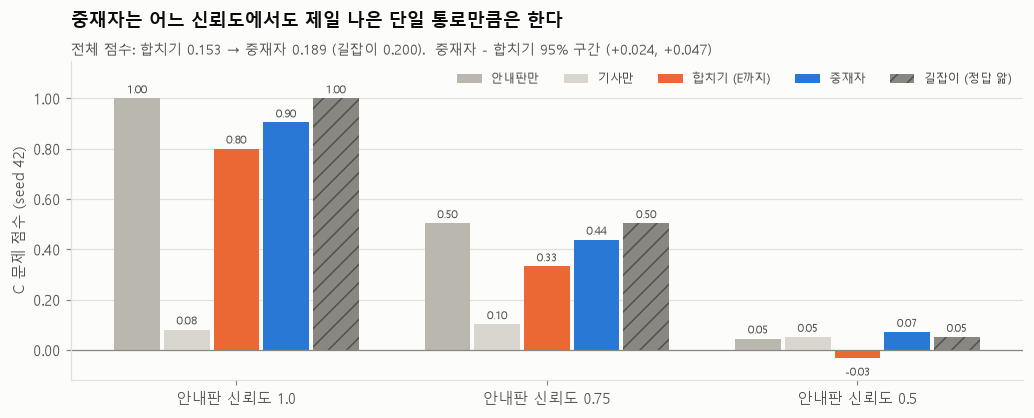

기준: {'1_beats_merge': True, '2_no_worse_than_best_single_channel': True, '3_learns_within_session': False, '4_no_conflict_unchanged': True}
기준 3 (r=0.5 세션 안에서 나아지나): 앞 0.080 → 뒤 0.064, 차이 구간 [-0.1611, 0.1192]


In [2]:
f = M.f_conflict()
colors = {"안내판만": V.NEUTRAL, "기사만": "#d8d6cf", "합치기 (E까지)": V.ORANGE, "중재자": V.BLUE, "길잡이 (정답 앎)": V.MUTED}
fig, ax = plt.subplots(figsize=(9.5, 3.9))
x = np.arange(len(f["levels"])); w = 0.16
for i, name in enumerate(f["systems"]):
    vals = f["c_only"][name]
    xs = x + (i - 2) * w
    ax.bar(xs, vals, width=w * 0.92, color=colors[name], label=name,
           hatch="//" if name.startswith("길잡이") else None, edgecolor=V.SURFACE if not name.startswith("길잡이") else V.TEXT_SECONDARY, lw=0)
    for xi, v in zip(xs, vals):
        ax.text(xi, v + (0.02 if v >= 0 else -0.07), f"{v:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [f"안내판 신뢰도 {lv}" for lv in f["levels"]]); ax.grid(axis="x", visible=False)
ax.set_ylim(-0.12, 1.15); ax.set_ylabel("C 문제 점수 (seed 42)"); ax.yaxis.set_major_formatter(plain)
ax.legend(fontsize=8, ncol=5, loc="upper right", bbox_to_anchor=(1, 1.0))
ax.set_title("중재자는 어느 신뢰도에서도 제일 나은 단일 통로만큼은 한다", pad=22)
V.note(ax, f"전체 점수: 합치기 {f['total']['합치기 (E까지)']:.3f} → 중재자 {f['total']['중재자']:.3f} (길잡이 {f['total']['길잡이 (정답 앎)']:.3f}).  "
           f"중재자 - 합치기 95% 구간 ({f['arbiter_minus_merge_ci'][0]:+.3f}, {f['arbiter_minus_merge_ci'][1]:+.3f})")
fig.tight_layout(); plt.show()
ws = f["within_session"]
print("기준:", f["criteria"])
print(f"기준 3 (r=0.5 세션 안에서 나아지나): 앞 {ws['first_half']:.3f} → 뒤 {ws['second_half']:.3f}, 차이 구간 {ws['difference_ci95']}")

**기준 4개 중 3개 통과.** 떨어진 기준 3(세션 안에서 점점 나아지기)은 **세계가 허락하지 않는 효과**였다. 이상적인 판단자(베이즈)도 세션 안에서 +0.009밖에 못 나아진다. 중재자는 베이즈의 98%(문 점수 0.239 vs 0.244). 그래서 이후로는 "기준 정하기 전에 이상적인 판단자로 효과 크기부터 재기"가 규칙이 됐다.

### 중재자 학습 곡선: 데이터를 3배 넘게 늘려도 그대로

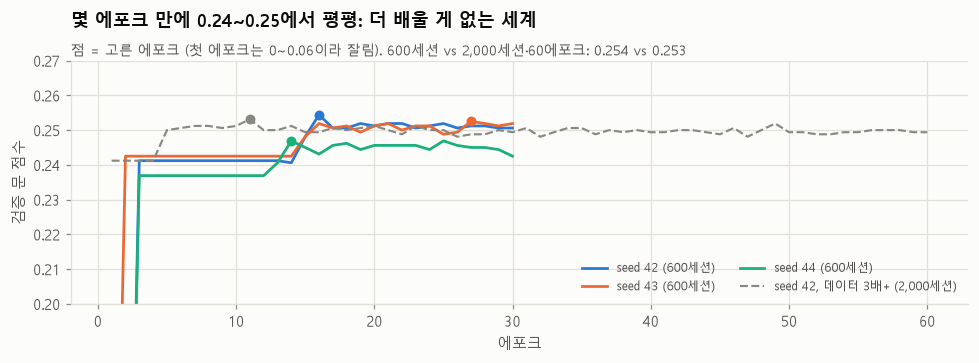

In [3]:
runs = M.arbiter_training()
fig, ax = plt.subplots(figsize=(9, 3.4))
seed_colors = {"42": V.BLUE, "43": V.ORANGE, "44": V.AQUA}
for r in runs:
    ax.plot(r["epochs"], r["score"], color=V.MUTED if r["v2"] else seed_colors[r["seed"]],
            ls="--" if r["v2"] else "-", lw=1.4 if r["v2"] else 1.8, label=r["label"])
    sel = r["epochs"].index(r["selected"])
    ax.scatter([r["selected"]], [r["score"][sel]], s=30, zorder=3, color=V.MUTED if r["v2"] else seed_colors[r["seed"]])
ax.set_xlabel("에포크"); ax.set_ylabel("검증 문 점수"); ax.yaxis.set_major_formatter(plain)
ax.set_ylim(0.2, 0.27)
ax.legend(fontsize=8, loc="lower right", ncol=2)
ax.set_title("몇 에포크 만에 0.24~0.25에서 평평: 더 배울 게 없는 세계", pad=22)
V.note(ax, "점 = 고른 에포크 (첫 에포크는 0~0.06이라 잘림). 600세션 vs 2,000세션·60에포크: 0.254 vs 0.253")
fig.tight_layout(); plt.show()

## 2. G: 한 번 더 물어볼까? → 재 보니 배울 게 없다

새 부품을 만들기 **전에** 효과 크기부터 쟀다. 사령탑은 그대로 두고, "이 열쇠를 얼마나 확신하나" 입력만 중재자의 확신으로 바꿨다.

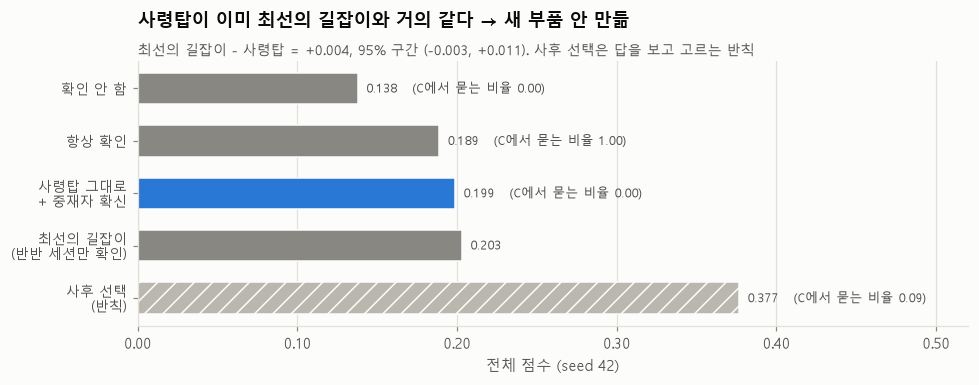

In [4]:
g = M.g_verify()
rows = g["rows"]
fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(rows))[::-1]
for yi, r in zip(y, rows):
    color = V.NEUTRAL if r["cheat"] else (V.BLUE if r["label"].startswith("사령탑") else V.MUTED)
    ax.barh(yi, r["net"], color=color, height=0.6, hatch="//" if r["cheat"] else None, edgecolor=V.SURFACE)
    ask = "" if r["asks"] is None else f"   (C에서 묻는 비율 {r['asks']:.2f})"
    ax.text(r["net"] + 0.005, yi, f"{r['net']:.3f}{ask}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(y, [r["label"] for r in rows], fontsize=9); ax.grid(axis="y", visible=False)
ax.set_xlim(0, 0.52); ax.set_xlabel("전체 점수 (seed 42)"); ax.xaxis.set_major_formatter(plain)
lo, hi = g["best_guide_minus_router_ci"]
ax.set_title("사령탑이 이미 최선의 길잡이와 거의 같다 → 새 부품 안 만듦", pad=22)
V.note(ax, f"최선의 길잡이 - 사령탑 = +0.004, 95% 구간 ({lo:+.3f}, {hi:+.3f}). 사후 선택은 답을 보고 고르는 반칙")
fig.tight_layout(); plt.show()

확인이 별 도움이 안 되는 이유: 기사 부품이 결론을 내는 게 45%이고 그중 66%만 맞는다. 얻는 정보가 묻는 비용(0.05)과 비슷하다. 기사 부품이 좋아지면 다시 잰다.

## 3. 감사: "학습한 걸로 시험하면 당연히 잘 나오는 거 아냐?"

### 3-1. 유출: 읽기 전문가가 시험 기사를 미리 봤다 (40%). 그런데 부풀었나?

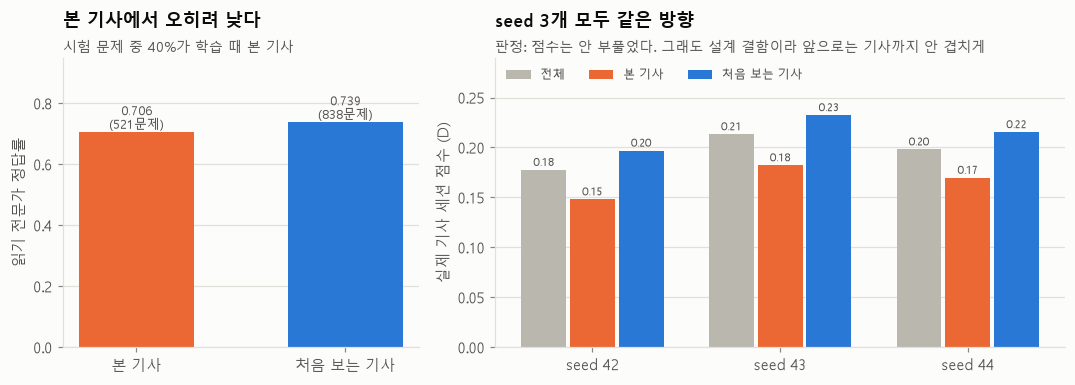

In [5]:
lk = M.audit_leakage()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})
ax = axes[0]
names = list(lk["reader"])
vals = [lk["reader"][n]["rate"] for n in names]
ax.bar(names, vals, color=[V.ORANGE, V.BLUE], width=0.55)
for i, n in enumerate(names):
    ax.text(i, vals[i] + 0.01, f"{vals[i]:.3f}\n({lk['reader'][n]['questions']}문제)", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_ylim(0, 0.95); ax.set_ylabel("읽기 전문가 정답률"); ax.grid(axis="x", visible=False)
ax.set_title("본 기사에서 오히려 낮다", pad=20)
V.note(ax, f"시험 문제 중 {lk['test_seen_share']:.0%}가 학습 때 본 기사")
ax = axes[1]
seeds = list(lk["sessions"]); x = np.arange(len(seeds)); w = 0.26
for i, (key, label, color) in enumerate([("score", "전체", V.NEUTRAL), ("seen_passage", "본 기사", V.ORANGE), ("unseen_passage", "처음 보는 기사", V.BLUE)]):
    v = [lk["sessions"][s][key] for s in seeds]
    ax.bar(x + (i - 1) * w, v, width=w * 0.92, color=color, label=label)
    for xi, vi in zip(x + (i - 1) * w, v):
        ax.text(xi, vi + 0.004, f"{vi:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [f"seed {s}" for s in seeds]); ax.grid(axis="x", visible=False)
ax.set_ylim(0, 0.29); ax.set_ylabel("실제 기사 세션 점수 (D)")
ax.legend(fontsize=8, ncol=3, loc="upper left")
ax.set_title("seed 3개 모두 같은 방향", pad=20)
V.note(ax, "판정: 점수는 안 부풀었다. 그래도 설계 결함이라 앞으로는 기사까지 안 겹치게")
fig.tight_layout(); plt.show()

### 3-2. seed 3개 + 세션 단위 구간으로 다시 재기

같은 세션 안 문제들은 서로 독립이 아니다. 그래서 **문제 단위**로 다시 뽑으면 구간이 실제보다 좁다. **세션 단위**로 다시 쟀다.

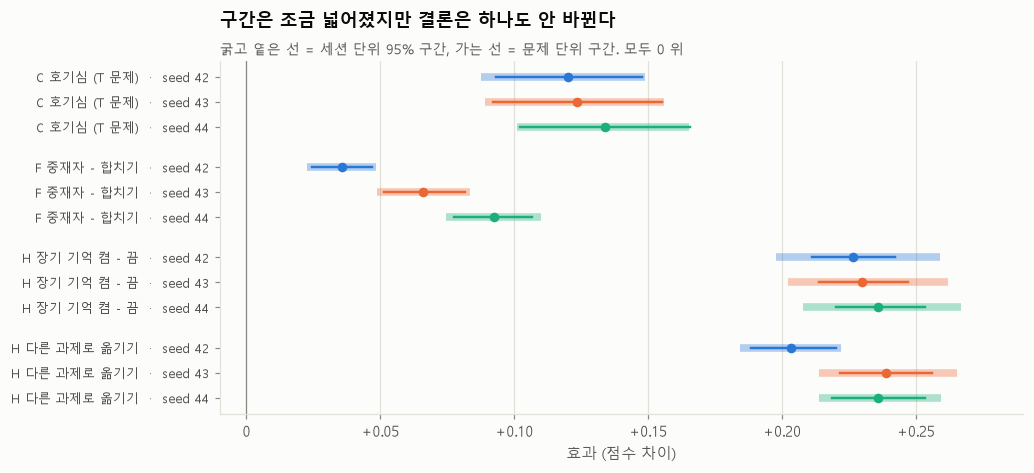

In [6]:
eff = M.audit_effects()
stages = list(dict.fromkeys(r["stage"] for r in eff))
fig, ax = plt.subplots(figsize=(9.5, 4.4))
seed_colors = {"42": V.BLUE, "43": V.ORANGE, "44": V.AQUA}
ylabels, ypos = [], []
y = 0
for st in stages[::-1]:
    for r in [e for e in eff if e["stage"] == st][::-1]:
        c = seed_colors[r["seed"]]
        ax.plot(r["ci_sessions"], [y, y], color=c, lw=5, alpha=0.35, solid_capstyle="butt")
        ax.plot(r["ci_questions"], [y, y], color=c, lw=1.6)
        ax.scatter([r["effect"]], [y], color=c, s=28, zorder=3)
        ypos.append(y); ylabels.append(f"{st}  ·  seed {r['seed']}")
        y += 1
    y += 0.6
ax.axvline(0, color=V.MUTED, lw=0.8)
ax.set_yticks(ypos, ylabels, fontsize=8.5); ax.grid(axis="y", visible=False)
ax.set_xlim(-0.01, 0.29); ax.xaxis.set_major_formatter(signed); ax.set_xlabel("효과 (점수 차이)")
ax.set_title("구간은 조금 넓어졌지만 결론은 하나도 안 바뀐다", pad=22)
V.note(ax, "굵고 옅은 선 = 세션 단위 95% 구간, 가는 선 = 문제 단위 구간. 모두 0 위")
fig.tight_layout(); plt.show()

감사 7절: seed 43·44로 다시 재다가 **F의 '사실 바꾸기' 배선 버그**를 찾았다(seed 43에서 전달 0%). 고친 뒤 seed 3개 모두 전달 100%이고, seed 42 숫자는 하나도 안 바뀌었다. 위 F 줄은 고친 뒤 숫자다.

감사에서 고친 **과장 3개**(그림 없음): "0.28B 전문가가 1.2B 범용 모델을 이김"은 학습 여부가 달라 공정한 비교가 아니다 / 만든 세계 실험은 언어 이해가 아니라 처음 보는 **조합**에서의 판단을 시험했다(시험 문장 100%가 학습 때 나옴) / 장기 기억 효과 크기(+0.23)는 세계가 얼마나 반복되냐(69%)에 달린 숫자다.

### 3-3. 학습 범위 밖: 처음 보는 안내판 신뢰도

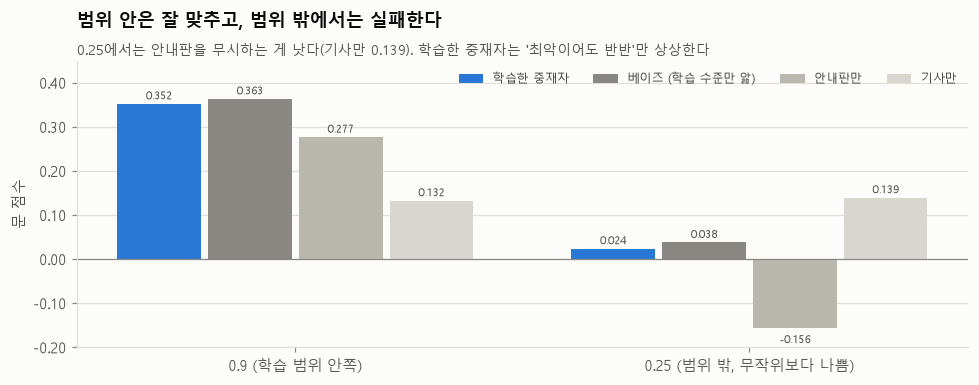

In [7]:
un = M.audit_unseen_accuracy()
names = list(un["0.9"])
colors = [V.BLUE, V.MUTED, V.NEUTRAL, "#d8d6cf"]
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(2); w = 0.2
for i, n in enumerate(names):
    v = [un[lv][n] for lv in ("0.9", "0.25")]
    xs = x + (i - 1.5) * w
    ax.bar(xs, v, width=w * 0.92, color=colors[i], label=n)
    for xi, vi in zip(xs, v):
        ax.text(xi, vi + (0.01 if vi >= 0 else -0.035), f"{vi:.3f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, ["0.9 (학습 범위 안쪽)", "0.25 (범위 밖, 무작위보다 나쁨)"]); ax.grid(axis="x", visible=False)
ax.set_ylim(-0.2, 0.45); ax.set_ylabel("문 점수"); ax.yaxis.set_major_formatter(plain)
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.set_title("범위 안은 잘 맞추고, 범위 밖에서는 실패한다", pad=22)
V.note(ax, "0.25에서는 안내판을 무시하는 게 낫다(기사만 0.139). 학습한 중재자는 '최악이어도 반반'만 상상한다")
fig.tight_layout(); plt.show()

## 4. I: 예시를 늘리는 대신 표현을 바꾼다 → 세는 중재자

**세는 중재자**: 통로마다 "말한 횟수, 맞은 횟수"를 세서 신뢰도를 베타 분포로 추정한다. 신뢰도가 0이든 1이든 같은 계산이 통하고, 무작위보다 나쁜 통로는 자기가 말한 열쇠를 오히려 깎는다. 경험에서 배우는 건 사전 믿음 숫자 2개(α, β)뿐.

판정은 **새 시험 세계**, seed 3개, 세션 단위 구간.

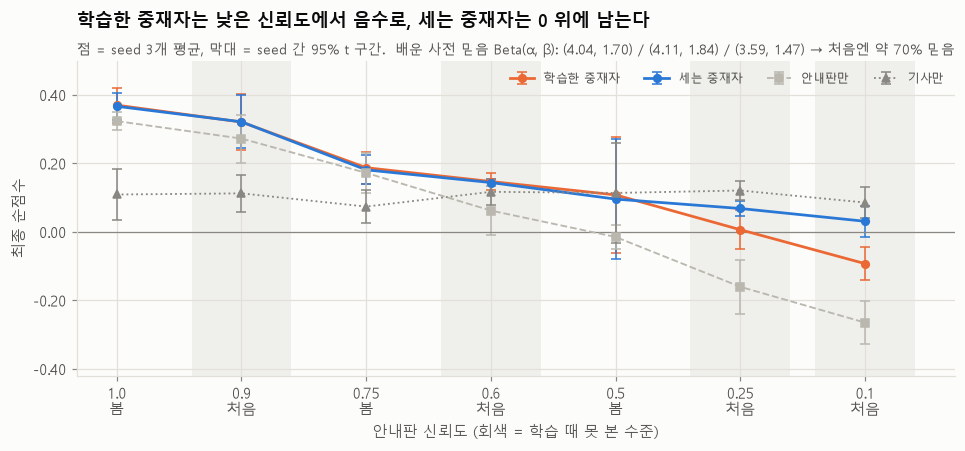

In [8]:
ia = M.i_by_accuracy()
pri = M.i_priors()
lv = ia["levels"]; x = np.arange(len(lv))
styles = {"학습한 중재자": (V.ORANGE, "o", "-"), "세는 중재자": (V.BLUE, "o", "-"), "안내판만": (V.NEUTRAL, "s", "--"), "기사만": (V.MUTED, "^", ":")}
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for i, seen in enumerate(ia["seen"]):
    if not seen:
        ax.axvspan(i - 0.4, i + 0.4, color=V.GRID, alpha=0.45, lw=0)
for name, (c, m, ls) in styles.items():
    s = ia["systems"][name]
    ax.errorbar(x, s["mean"], yerr=s["ci"], color=c, marker=m, ls=ls, lw=1.8 if "중재자" in name else 1.2,
                ms=5, capsize=3, elinewidth=1, label=name)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [f"{l}\n{'봄' if s else '처음'}" for l, s in zip(lv, ia["seen"])])
ax.set_xlabel("안내판 신뢰도 (회색 = 학습 때 못 본 수준)"); ax.set_ylabel("최종 순점수")
ax.yaxis.set_major_formatter(plain); ax.set_ylim(-0.42, 0.5)
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.set_title("학습한 중재자는 낮은 신뢰도에서 음수로, 세는 중재자는 0 위에 남는다", pad=22)
V.note(ax, "점 = seed 3개 평균, 막대 = seed 간 95% t 구간.  배운 사전 믿음 Beta(α, β): "
       + " / ".join(f"({a:.2f}, {b:.2f})" for a, b in pri.values()) + " → 처음엔 약 70% 믿음")
fig.tight_layout(); plt.show()

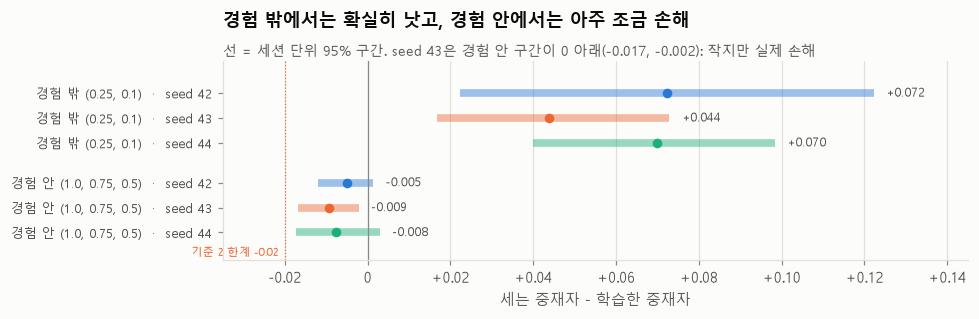

In [9]:
gaps = M.i_gaps()
groups = list(dict.fromkeys(r["group"] for r in gaps))
fig, ax = plt.subplots(figsize=(9, 3.0))
y, ypos, ylab = 0, [], []
for gname in groups[::-1]:
    for r in [g for g in gaps if g["group"] == gname][::-1]:
        c = seed_colors[r["seed"]]
        ax.plot(r["ci"], [y, y], color=c, lw=5, alpha=0.45, solid_capstyle="butt")
        ax.scatter([r["effect"]], [y], color=c, s=28, zorder=3)
        ax.text(r["ci"][1] + 0.003, y, f"{r['effect']:+.3f}", va="center", fontsize=8, color=V.TEXT_SECONDARY)
        ypos.append(y); ylab.append(f"{gname}  ·  seed {r['seed']}"); y += 1
    y += 0.6
ax.axvline(0, color=V.MUTED, lw=0.8)
ax.axvline(-0.02, color=V.ORANGE, lw=0.8, ls=":")
ax.text(-0.0205, -0.8, "기준 2 한계 -0.02 ", fontsize=7.5, color=V.ORANGE, va="center", ha="right")
ax.set_yticks(ypos, ylab, fontsize=8.5); ax.grid(axis="y", visible=False)
ax.set_ylim(-1.1, y - 0.3)
ax.xaxis.set_major_formatter(signed); ax.set_xlim(-0.035, 0.145); ax.set_xlabel("세는 중재자 - 학습한 중재자")
ax.set_title("경험 밖에서는 확실히 낫고, 경험 안에서는 아주 조금 손해", pad=22)
V.note(ax, "선 = 세션 단위 95% 구간. seed 43은 경험 안 구간이 0 아래(-0.017, -0.002): 작지만 실제 손해")
fig.tight_layout(); plt.show()

**졸업 (기준 3개 모두 통과).** 솔직한 점:
- 아주 낮은 신뢰도에서는 **기사만 쓰는 것보다 아직 낮다**(예: 0.016 vs 0.075). 처음엔 70% 믿다가 증거가 쌓여야 바뀐다. "빨리 의심하기"는 남은 문제.
- 계산 구조는 사람이 설계했고, 배운 건 숫자 2개다. 경험 밖으로 넘어가는 힘은 상당 부분 **표현을 잘 고른 데서** 나온다.
- 결정: 앞으로 새 실험의 기본은 세는 중재자.

## 5. K: 믿던 안내판이 갑자기 배신하면?

세는 중재자는 "이 통로는 원래 70%"는 다루지만, **갑자기 나빠지는 것**은 못 알아챈다. **변화 감지 중재자**는 통로마다 "마지막 변화 이후 몇 번째인가"를 추적한다(베이즈 온라인 변화점 검출). 배울 숫자는 α, β, 변화율 h 세 개.

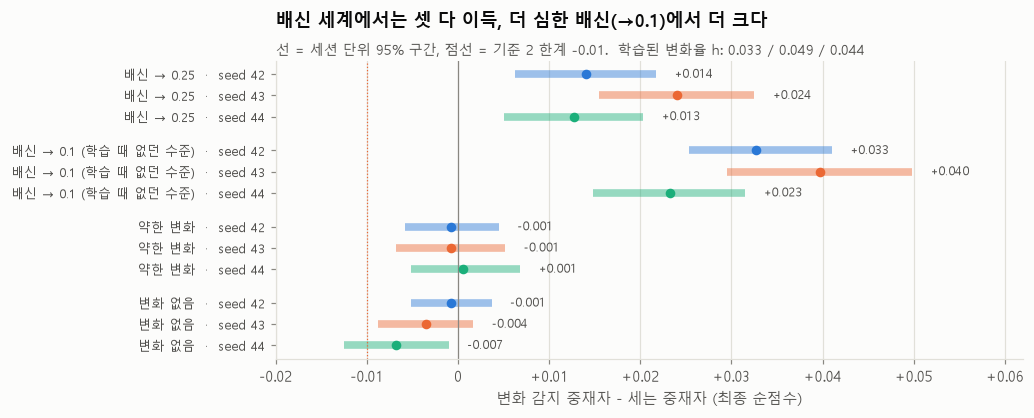

In [10]:
kg = M.k_gaps()
worlds = list(dict.fromkeys(r["world"] for r in kg))
hz = M.k_hazards()
fig, ax = plt.subplots(figsize=(9.5, 3.9))
y, ypos, ylab = 0, [], []
for wname in worlds[::-1]:
    for r in [g for g in kg if g["world"] == wname][::-1]:
        c = seed_colors[r["seed"]]
        ax.plot(r["ci"], [y, y], color=c, lw=5, alpha=0.45, solid_capstyle="butt")
        ax.scatter([r["effect"]], [y], color=c, s=28, zorder=3)
        ax.text(max(r["ci"][1], r["effect"]) + 0.002, y, f"{r['effect']:+.3f}", va="center", fontsize=8, color=V.TEXT_SECONDARY)
        ypos.append(y); ylab.append(f"{wname.replace(chr(10), ' ')}  ·  seed {r['seed']}"); y += 1
    y += 0.6
ax.axvline(0, color=V.MUTED, lw=0.8)
ax.axvline(-0.01, color=V.ORANGE, lw=0.8, ls=":")
ax.set_yticks(ypos, ylab, fontsize=8.2); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(signed); ax.set_xlim(-0.02, 0.062); ax.set_xlabel("변화 감지 중재자 - 세는 중재자 (최종 순점수)")
ax.set_title("배신 세계에서는 셋 다 이득, 더 심한 배신(→0.1)에서 더 크다", pad=22)
V.note(ax, "선 = 세션 단위 95% 구간, 점선 = 기준 2 한계 -0.01.  학습된 변화율 h: "
       + " / ".join(f"{h:.3f}" for h in hz.values()))
fig.tight_layout(); plt.show()

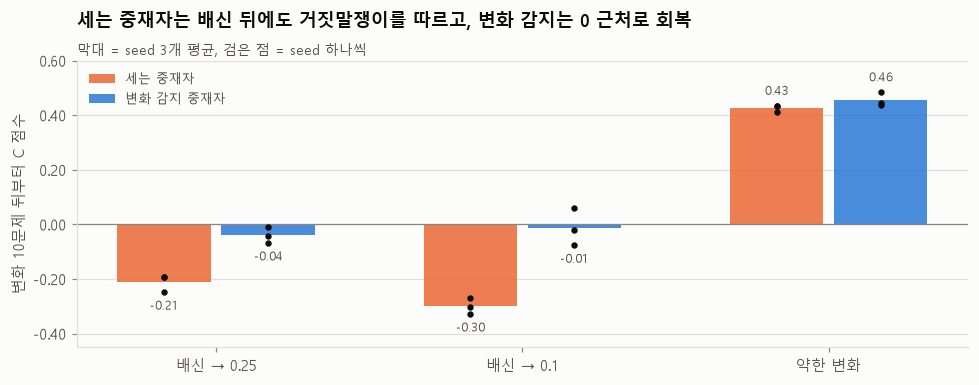

In [11]:
ab = M.k_after_betrayal()
fig, ax = plt.subplots(figsize=(9, 3.6))
wl = list(ab); x = np.arange(len(wl)); w = 0.34
for i, (name, c) in enumerate([("세는 중재자", V.ORANGE), ("변화 감지 중재자", V.BLUE)]):
    means = [np.mean(ab[k][name]) for k in wl]
    xs = x + (i - 0.5) * w
    ax.bar(xs, means, width=w * 0.9, color=c, alpha=0.85, label=name)
    for xi, k in zip(xs, wl):
        vals = ab[k][name]
        ax.scatter([xi] * len(vals), vals, color=V.TEXT, s=10, zorder=3)
    for xi, k, m in zip(xs, wl, means):
        vals = ab[k][name]
        ty = max(max(vals), m) + 0.03 if m >= 0 else min(min(vals), m) - 0.03
        ax.text(xi, ty, f"{m:.2f}", ha="center", va="bottom" if m >= 0 else "top", fontsize=8, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, wl); ax.grid(axis="x", visible=False)
ax.set_ylim(-0.45, 0.6); ax.set_ylabel("변화 10문제 뒤부터 C 점수"); ax.yaxis.set_major_formatter(plain)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("세는 중재자는 배신 뒤에도 거짓말쟁이를 따르고, 변화 감지는 0 근처로 회복", pad=22)
V.note(ax, "막대 = seed 3개 평균, 검은 점 = seed 하나씩")
fig.tight_layout(); plt.show()

## 6. 정리

- **F 중재자**: "누구를 믿을지" 배우는 원리(1단계 신뢰)가 사람이 아니라 **부품**을 상대로도 통한다. 이상적인 판단자의 98%. 기준 3은 세계가 허락하지 않는 효과라 떨어졌다.
- **G**: 만들기 전에 재 보니 얻을 게 최대 +0.004 → 안 만들었다.
- **감사**: 버그 1개 고침(seed 42 숫자는 그대로), 유출은 점수를 안 부풀림, 과장 3개 고침. 앞으로 seed 3개 + 세션 단위 구간 + 학습 범위 밖 시험이 기본.
- **I 세는 중재자**: 처음 보는 나쁜 안내판에서도 0 아래로 안 떨어진다. 대가는 경험 안에서 −0.01 정도.
- **K 변화 감지 중재자**: 배신을 알아채고 회복한다. 장치만으론 부족했고 **배신을 겪어 본 경험**이 있어야 변화율이 의미 있게 배워졌다(약한 변화만 겪으면 h ≈ 0.001). 변화 없을 때 비용은 −0.01 안(seed 44는 작지만 실제 비용).